In [15]:
import torch
import numpy as np
import anndata as ad
import scanpy as sc
import phate
from scipy.spatial.distance import pdist, squareform
from pathlib import Path

from data.splitters import (
    SplitConfig,
    apply_holdout_masks,
    load_cell_names_csv,
    load_manifest_json,
    make_split_artifacts,
    save_cell_names_csv,
    select_stratified_cell_names,
    validate_no_leakage,
)
from models.autoencoder import NBAutoEncoder
from training.losses import LossComposer, NBReconLoss, DistancePreservationLoss
from training.trainer_ae import make_ae_dataloader, train_ae_two_phase


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
config = SplitConfig()
artifacts = make_split_artifacts(config)

subsample_h5ad_path = Path(f"sciplex_subsample_{artifacts.tag}.h5ad")
ae_model_path = Path(f"sciplex_ae_model_{artifacts.tag}.pt")
ae_space_path = Path(f"sciplex_ae_space_{artifacts.tag}.pkl")

required = {
    "subsample_h5ad": subsample_h5ad_path,
    "holdout_manifest": artifacts.holdout_json_path,
}
missing = [f"{name}: {path}" for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required artifacts for AE training:\n  - " + "\n  - ".join(missing))

adata_full = ad.read_h5ad(subsample_h5ad_path)
manifest = load_manifest_json(artifacts.holdout_json_path)
print(f"Using split tag: {artifacts.tag}")


Using split tag: strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle


In [18]:
from data.space import SpaceManager

space = SpaceManager(mode="log1p", n_hvgs=2000)
space.fit(adata_full)
hvg_names = space.hvg_names

adata_full_hvg = adata_full[:, hvg_names].copy()

masks = apply_holdout_masks(adata_full_hvg, manifest)
validate_no_leakage(adata_full_hvg, masks, product_name_col="product_name")

adata_pool = adata_full_hvg[masks["is_train"]].copy()
print(f"AE training pool size (non-held-out): {adata_pool.n_obs}")

if artifacts.ae_train_cells_csv_path.exists():
    train_cell_names = load_cell_names_csv(artifacts.ae_train_cells_csv_path)
    print(f"Loaded AE train cells from {artifacts.ae_train_cells_csv_path}")
else:
    train_cell_names = select_stratified_cell_names(
        adata_pool,
        n_cells=config.ae_subsample_n_cells,
        seed=config.ae_subsample_seed,
        group_cols=config.ae_subsample_group_cols,
    )
    save_cell_names_csv(train_cell_names, artifacts.ae_train_cells_csv_path)
    print(f"Saved AE train cells to {artifacts.ae_train_cells_csv_path}")

missing_cells = sorted(set(train_cell_names) - set(adata_pool.obs_names))
if missing_cells:
    raise ValueError(f"AE train cell list contains out-of-pool cells. Example: {missing_cells[:5]}")

n_train_cells = len(train_cell_names)
adata_train = adata_full_hvg[train_cell_names, :].copy()

# prepare log1p-normalized copy for PHATE
adata_copy = adata_train.copy()
sc.pp.normalize_total(adata_copy, target_sum=1e4)
sc.pp.log1p(adata_copy)

x_train_log1p = adata_copy.X.toarray() if hasattr(adata_copy.X, "toarray") else adata_copy.X

# compute PHATE diffusion potential distances
print("fitting PHATE to compute diffusion potential distances...")
phate_op = phate.PHATE(n_components=2, knn=5, n_landmark=min(2000, n_train_cells), verbose=True)
phate_op.fit(x_train_log1p)

# diff_potential: (n_cells, n_landmarks) -- rows are potential vectors per cell
# pass embeddings directly; AEBatchDataset computes pdist per batch on the fly
diff_potential = phate_op.diff_potential
print(f"diffusion potential shape: {diff_potential.shape}")

train_loader = make_ae_dataloader(
    adata_train,
    distances=diff_potential,
    batch_size=256,
    shuffle=True,
)


/nfs/roberts/scratch/pi_sk2433/dac227/FlatCFM/data/space.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  sc.pp.highly_variable_genes(temp_adata, n_top_genes=self.n_hvgs, flavor="seurat_v3", subset=False)


AE training pool size (non-held-out): 51147
Saved AE train cells to artifacts/splits/sciplex_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle_ae_train_cells.csv
fitting PHATE to compute diffusion potential distances...
Running PHATE on 50000 observations and 2000 variables.
Calculating graph and diffusion operator...
  Calculating PCA...
  Calculated PCA in 2.41 seconds.
  Calculating KNN search...
  Calculated KNN search in 0.92 seconds.
  Calculating affinities...
  Calculated affinities in 1.08 seconds.
Calculated graph and diffusion operator in 4.52 seconds.
Calculating landmark operator...
  Calculating SVD...
  Calculated SVD in 3.45 seconds.
  Calculating KMeans...
  Calculated KMeans in 2.71 seconds.
Calculated landmark operator in 6.16 seconds.
Calculating optimal t...
  Automatically selected t = 12
Calculated optimal t in 0.73 seconds.
Calculating diffusion potential...
Calculated diffusion potential in 0.17 seconds.
diffusion potential shape: (50000, 2000

In [19]:
n_genes = adata_train.shape[1]
latent_dim = 128
model = NBAutoEncoder(n_genes=n_genes, latent_dim=latent_dim, hidden_dim=256, n_layers=3).to(device)

reconn_loss = NBReconLoss()
distance_loss = DistancePreservationLoss()

loss_map = {
    "recon": reconn_loss,
    "distance": distance_loss,
}

phase_1_weights = {
    "recon": 0.0,
    "distance": 1.0,
}

phase_2_weights = {
    "recon": 1.0,
    "distance": 0.0,
}

loss_composer = LossComposer(loss_map=loss_map, loss_weights=phase_1_weights)

In [20]:
history = train_ae_two_phase(
    model=model,
    train_loader=train_loader,
    loss_composer=loss_composer,
    phase1_weights=phase_1_weights,
    phase2_weights=phase_2_weights,
    learning_rate=1e-3,
    encoder_epochs=15,
    decoder_epochs=10,
    device=device,
)

torch.save(model.state_dict(), ae_model_path)

import pickle

# attach trained AE to space and upgrade mode
space.ae_model = model.cpu()  # store on cpu to avoid device issues on load
space.mode = "ae_latent"

with open(ae_space_path, "wb") as f:
    pickle.dump(space, f)

print(f"saved to {ae_model_path} and {ae_space_path}")


starting phase 1: training encoder with distance-based losses...
training nb autoencoder...
encoder frozen: False, decoder frozen: True
loss terms: ['recon', 'distance']


Epoch: 100%|██████████| 15/15 [00:08<00:00,  1.68it/s, train_loss=34.9357, val_loss=N/A, train_recon=0.0000, train_distance=34.9357]   




starting phase 2: training decoder with reconstruction-based losses...
training nb autoencoder...
encoder frozen: True, decoder frozen: False
loss terms: ['recon', 'distance']


Epoch: 100%|██████████| 10/10 [00:06<00:00,  1.63it/s, train_loss=0.0699, val_loss=N/A, train_recon=0.0699, train_distance=0.0000]

saved to sciplex_ae_model_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pt and sciplex_ae_space_strict_k562_seed42_subseed0_n100000_ae50000_strat-cell_type-vehicle.pkl


In [21]:
history

{'phase1': {'train_loss': [4221.391401174117,
   219.91269053245077,
   142.270174571446,
   97.76274249018455,
   75.66469355991909,
   61.199653197307974,
   53.50776565318205,
   48.37137465574303,
   43.467000007629395,
   41.27447326815858,
   38.80758861619599,
   37.18911262434356,
   36.48473040911616,
   36.08957980603588,
   34.93565126341216],
  'val_loss': [],
  'individual_train_losses': defaultdict(list,
              {'recon': [0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0,
                0.0],
               'distance': [4221.391401174117,
                219.91269053245077,
                142.270174571446,
                97.76274249018455,
                75.66469355991909,
                61.199653197307974,
                53.50776565318

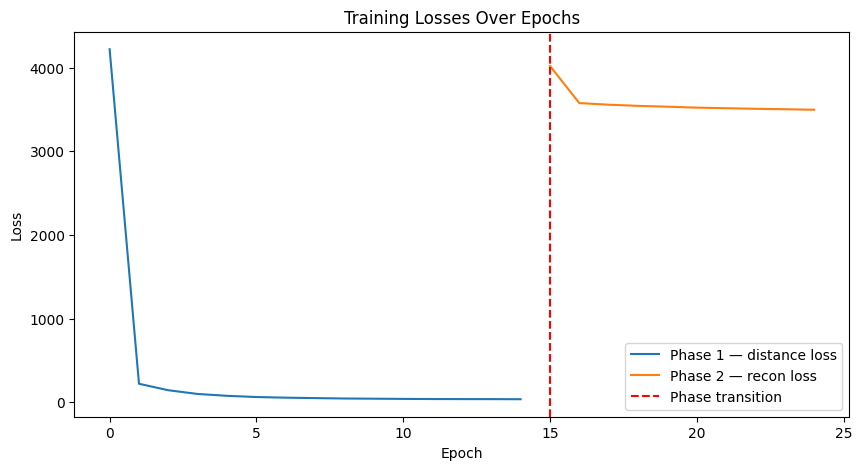

In [22]:
# plot losses
import matplotlib.pyplot as plt

p1_loss = history["phase1"]["train_loss"]
p2_loss = [loss * 50000 for loss in history["phase2"]["train_loss"]]
p1_epochs = len(p1_loss)

plt.figure(figsize=(10, 5))
plt.plot(range(p1_epochs), p1_loss, label="Phase 1 — distance loss")
plt.plot(range(p1_epochs, p1_epochs + len(p2_loss)), p2_loss, label="Phase 2 — recon loss")
plt.axvline(x=p1_epochs, color="red", linestyle="--", label="Phase transition")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses Over Epochs")
plt.legend()
plt.show()


In [23]:
# import matplotlib.pyplot as plt

# model.eval()

# X_raw_full = adata_train.X.toarray()

# chunk_size = 5000
# z_full = []

# with torch.no_grad():
#     for i in range(0, X_raw_full.shape[0], chunk_size):
#         X_chunk = X_raw_full[i : i + chunk_size]
#         X_chunk_tensor = torch.from_numpy(X_chunk).float().to(device)
#         z_chunk = model.encoder(X_chunk_tensor)
#         z_full.append(z_chunk.cpu().numpy())

# z_full = np.concatenate(z_full, axis=0)

# adata_train.obsm["X_ae_latent"] = z_full

# print("computing umap")

# sc.pp.neighbors(adata_train, use_rep="X_ae_latent")
# sc.tl.umap(adata_train)

# sc.pl.umap(adata_train, color="cell_type")

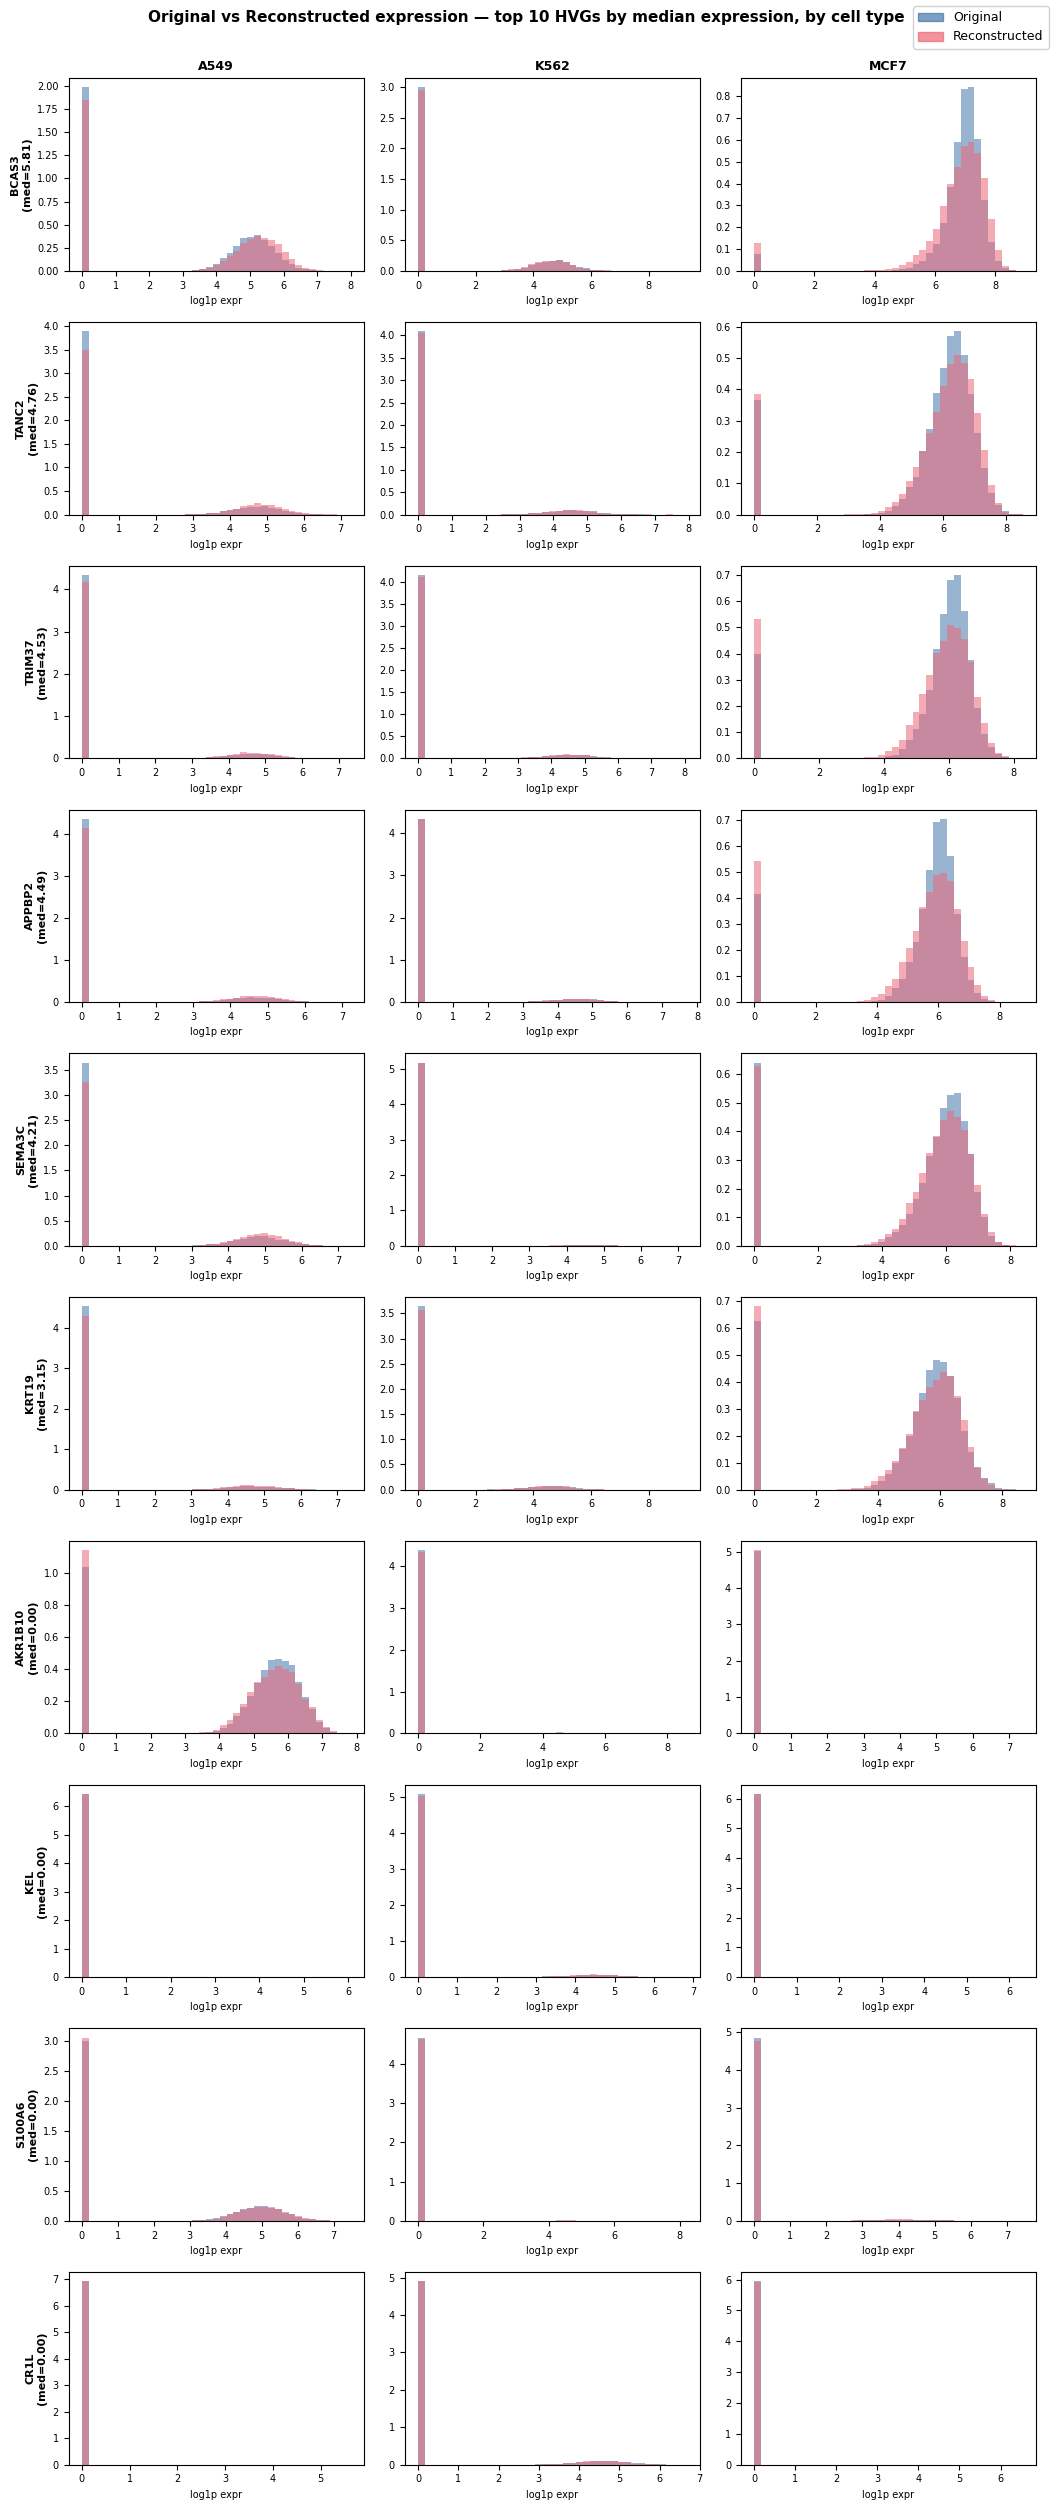

In [24]:
import matplotlib.pyplot as plt
import numpy as np

model = model.to(device)

# --- get reconstructed log-normalized expression (NB sample, not mean) ---
x_recon_log = model.reconstruct_log_norm(adata_train, sample=True, device=device).cpu().numpy()

# original log-normalized expression (log1p of raw counts scaled to 1e4)
X_raw = adata_train.X.toarray() if hasattr(adata_train.X, "toarray") else adata_train.X
lib_size = X_raw.sum(axis=1, keepdims=True)
x_orig_log = np.log1p(X_raw / np.maximum(lib_size, 1) * 1e4)

gene_names = adata_train.var_names.tolist()
cell_types = sorted(adata_train.obs["cell_type"].unique())

# select 10 genes with highest median expression across all cells
median_expr = np.median(x_orig_log, axis=0)
selected_gene_idx = np.argsort(median_expr)[-10:][::-1]
selected_genes = [gene_names[i] for i in selected_gene_idx]

n_genes_plot = len(selected_genes)
n_ct = len(cell_types)

fig, axes = plt.subplots(
    n_genes_plot,
    n_ct,
    figsize=(3.5 * n_ct, 2.5 * n_genes_plot),
    sharex=False,
    sharey=False,
)

ORIG_COLOR = "#4477AA"
RECON_COLOR = "#EE6677"
BINS = 40

for row, (gene, g_idx) in enumerate(zip(selected_genes, selected_gene_idx)):
    for col, ct in enumerate(cell_types):
        ax = axes[row, col]
        mask = adata_train.obs["cell_type"].values == ct

        orig_vals = x_orig_log[mask, g_idx]
        recon_vals = x_recon_log[mask, g_idx]

        x_max = max(orig_vals.max(), recon_vals.max())
        bins = np.linspace(0, x_max + 0.1, BINS)

        ax.hist(orig_vals, bins=bins, alpha=0.55, color=ORIG_COLOR, label="Original", density=True)
        ax.hist(recon_vals, bins=bins, alpha=0.55, color=RECON_COLOR, label="Reconstructed", density=True)

        if row == 0:
            ax.set_title(ct, fontsize=9, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{gene}\n(med={median_expr[g_idx]:.2f})", fontsize=8, fontweight="bold")
        ax.tick_params(labelsize=7)
        ax.set_xlabel("log1p expr", fontsize=7)

# shared legend
handles = [
    plt.Rectangle((0, 0), 1, 1, color=ORIG_COLOR, alpha=0.7, label="Original"),
    plt.Rectangle((0, 0), 1, 1, color=RECON_COLOR, alpha=0.7, label="Reconstructed"),
]
fig.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)

plt.suptitle(
    "Original vs Reconstructed expression — top 10 HVGs by median expression, by cell type",
    fontsize=11,
    fontweight="bold",
    y=1.002,
)
plt.tight_layout()
plt.show()


Mean W1 distance across all genes: 0.006


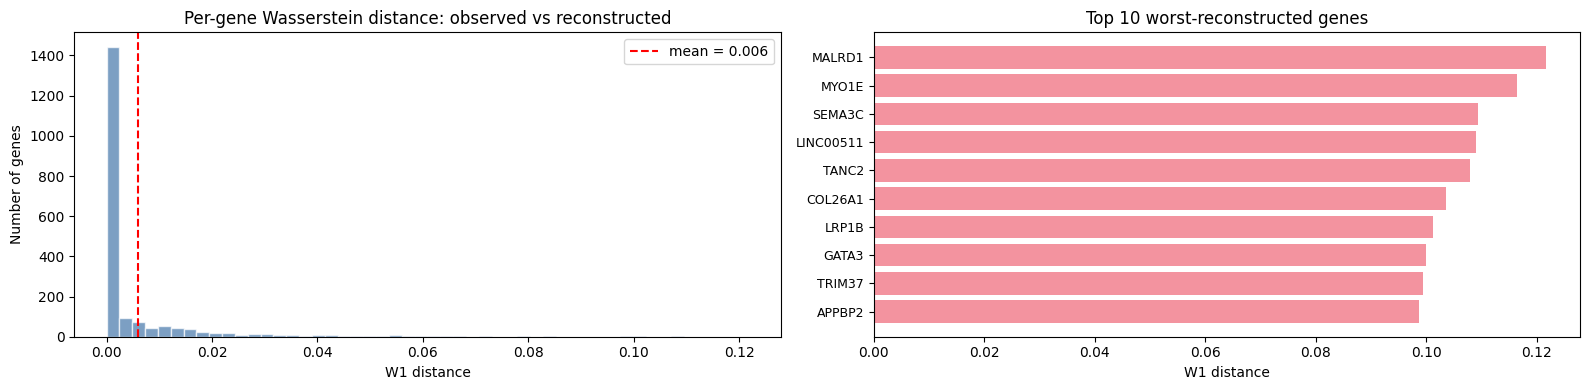

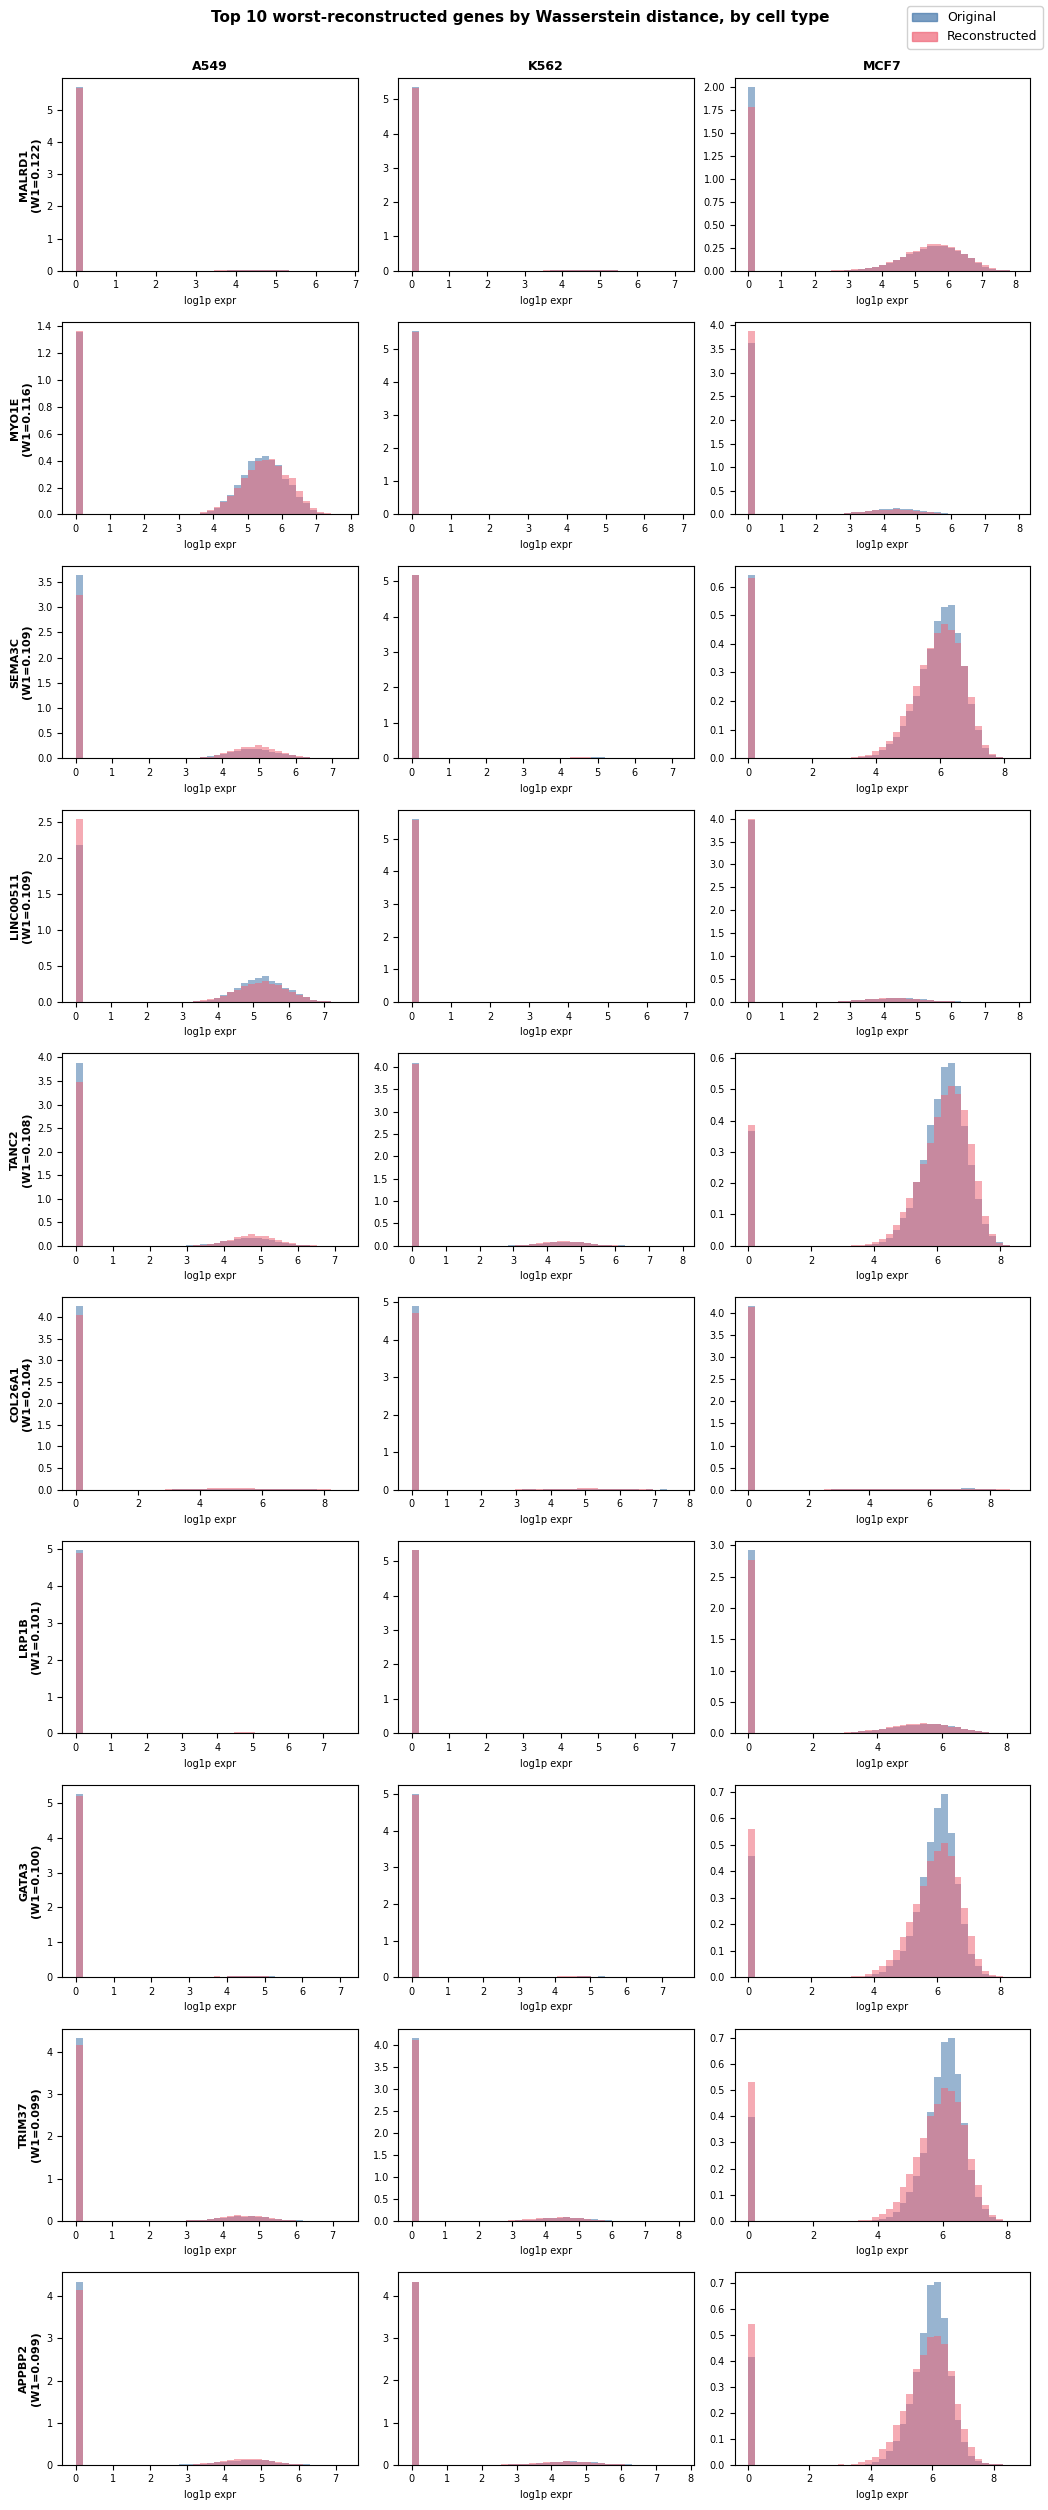

In [25]:
from scipy.stats import wasserstein_distance

# compute per-gene W2 distance between observed and reconstructed
gene_names = adata_train.var_names.tolist()
n_genes = len(gene_names)
w2_per_gene = np.zeros(n_genes)

for g in range(n_genes):
    w2_per_gene[g] = wasserstein_distance(x_orig_log[:, g], x_recon_log[:, g])

# print mean w2 across all genes
print(f"Mean W1 distance across all genes: {np.mean(w2_per_gene):.3f}")

# --- histogram of W2 across all genes ---
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

ax = axes[0]
ax.hist(w2_per_gene, bins=50, color="#4477AA", alpha=0.7, edgecolor="white")
ax.axvline(np.mean(w2_per_gene), color="red", linestyle="--", label=f"mean = {np.mean(w2_per_gene):.3f}")
ax.set_xlabel("W1 distance")
ax.set_ylabel("Number of genes")
ax.set_title("Per-gene Wasserstein distance: observed vs reconstructed")
ax.legend()

# --- top 10 worst genes bar chart ---
top10_idx = np.argsort(w2_per_gene)[::-1][:10]
top10_names = [gene_names[i] for i in top10_idx]
top10_vals = w2_per_gene[top10_idx]

ax = axes[1]
ax.barh(range(10), top10_vals[::-1], color="#EE6677", alpha=0.7)
ax.set_yticks(range(10))
ax.set_yticklabels(top10_names[::-1], fontsize=9)
ax.set_xlabel("W1 distance")
ax.set_title("Top 10 worst-reconstructed genes")
plt.tight_layout()
plt.show()

# --- histograms for the 10 worst genes ---
cell_types = sorted(adata_train.obs["cell_type"].unique())
n_ct = len(cell_types)
ORIG_COLOR = "#4477AA"
RECON_COLOR = "#EE6677"
BINS = 40

fig, axes = plt.subplots(10, n_ct, figsize=(3.5 * n_ct, 2.5 * 10), sharex=False, sharey=False)

for row, g_idx in enumerate(top10_idx):
    g_name = gene_names[g_idx]
    for col, ct in enumerate(cell_types):
        ax = axes[row, col]
        mask = adata_train.obs["cell_type"].values == ct

        orig_vals = x_orig_log[mask, g_idx]
        recon_vals = x_recon_log[mask, g_idx]

        x_max = max(orig_vals.max(), recon_vals.max())
        bins = np.linspace(0, x_max + 0.1, BINS)

        ax.hist(orig_vals, bins=bins, alpha=0.55, color=ORIG_COLOR, label="Original", density=True)
        ax.hist(recon_vals, bins=bins, alpha=0.55, color=RECON_COLOR, label="Reconstructed", density=True)

        if row == 0:
            ax.set_title(ct, fontsize=9, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"{g_name}\n(W1={w2_per_gene[g_idx]:.3f})", fontsize=8, fontweight="bold")
        ax.tick_params(labelsize=7)
        ax.set_xlabel("log1p expr", fontsize=7)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=ORIG_COLOR, alpha=0.7, label="Original"),
    plt.Rectangle((0, 0), 1, 1, color=RECON_COLOR, alpha=0.7, label="Reconstructed"),
]
fig.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
plt.suptitle(
    "Top 10 worst-reconstructed genes by Wasserstein distance, by cell type",
    fontsize=11,
    fontweight="bold",
    y=1.002,
)
plt.tight_layout()
plt.show()

Out-of-sample cells: 50000 (train: 50000, total: 100000)
In-sample  mean W1: 0.0059
Out-of-sample mean W1: 0.0064


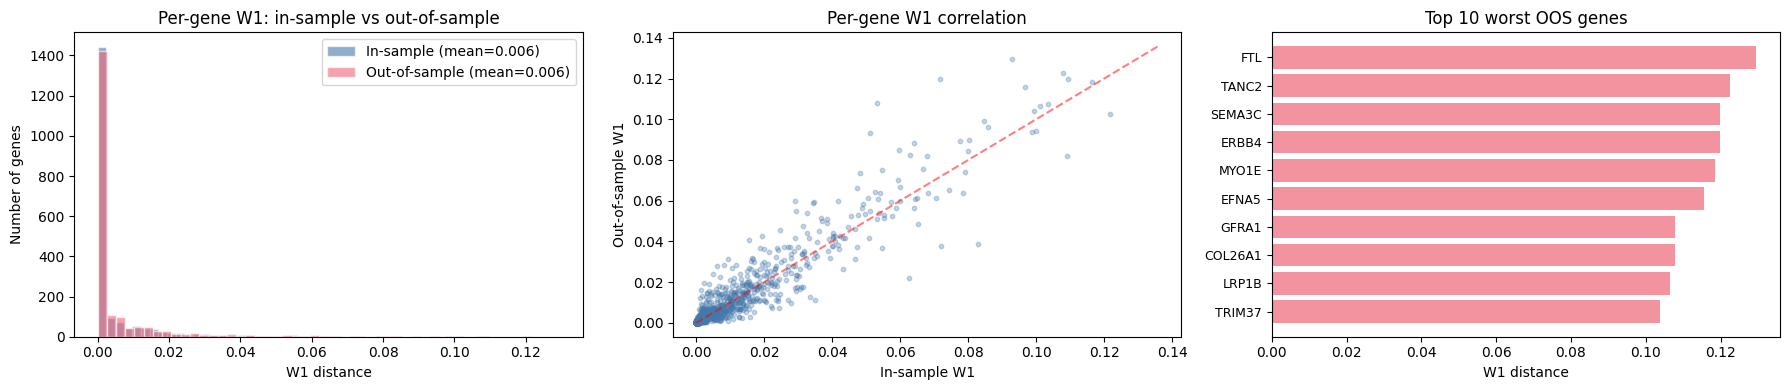

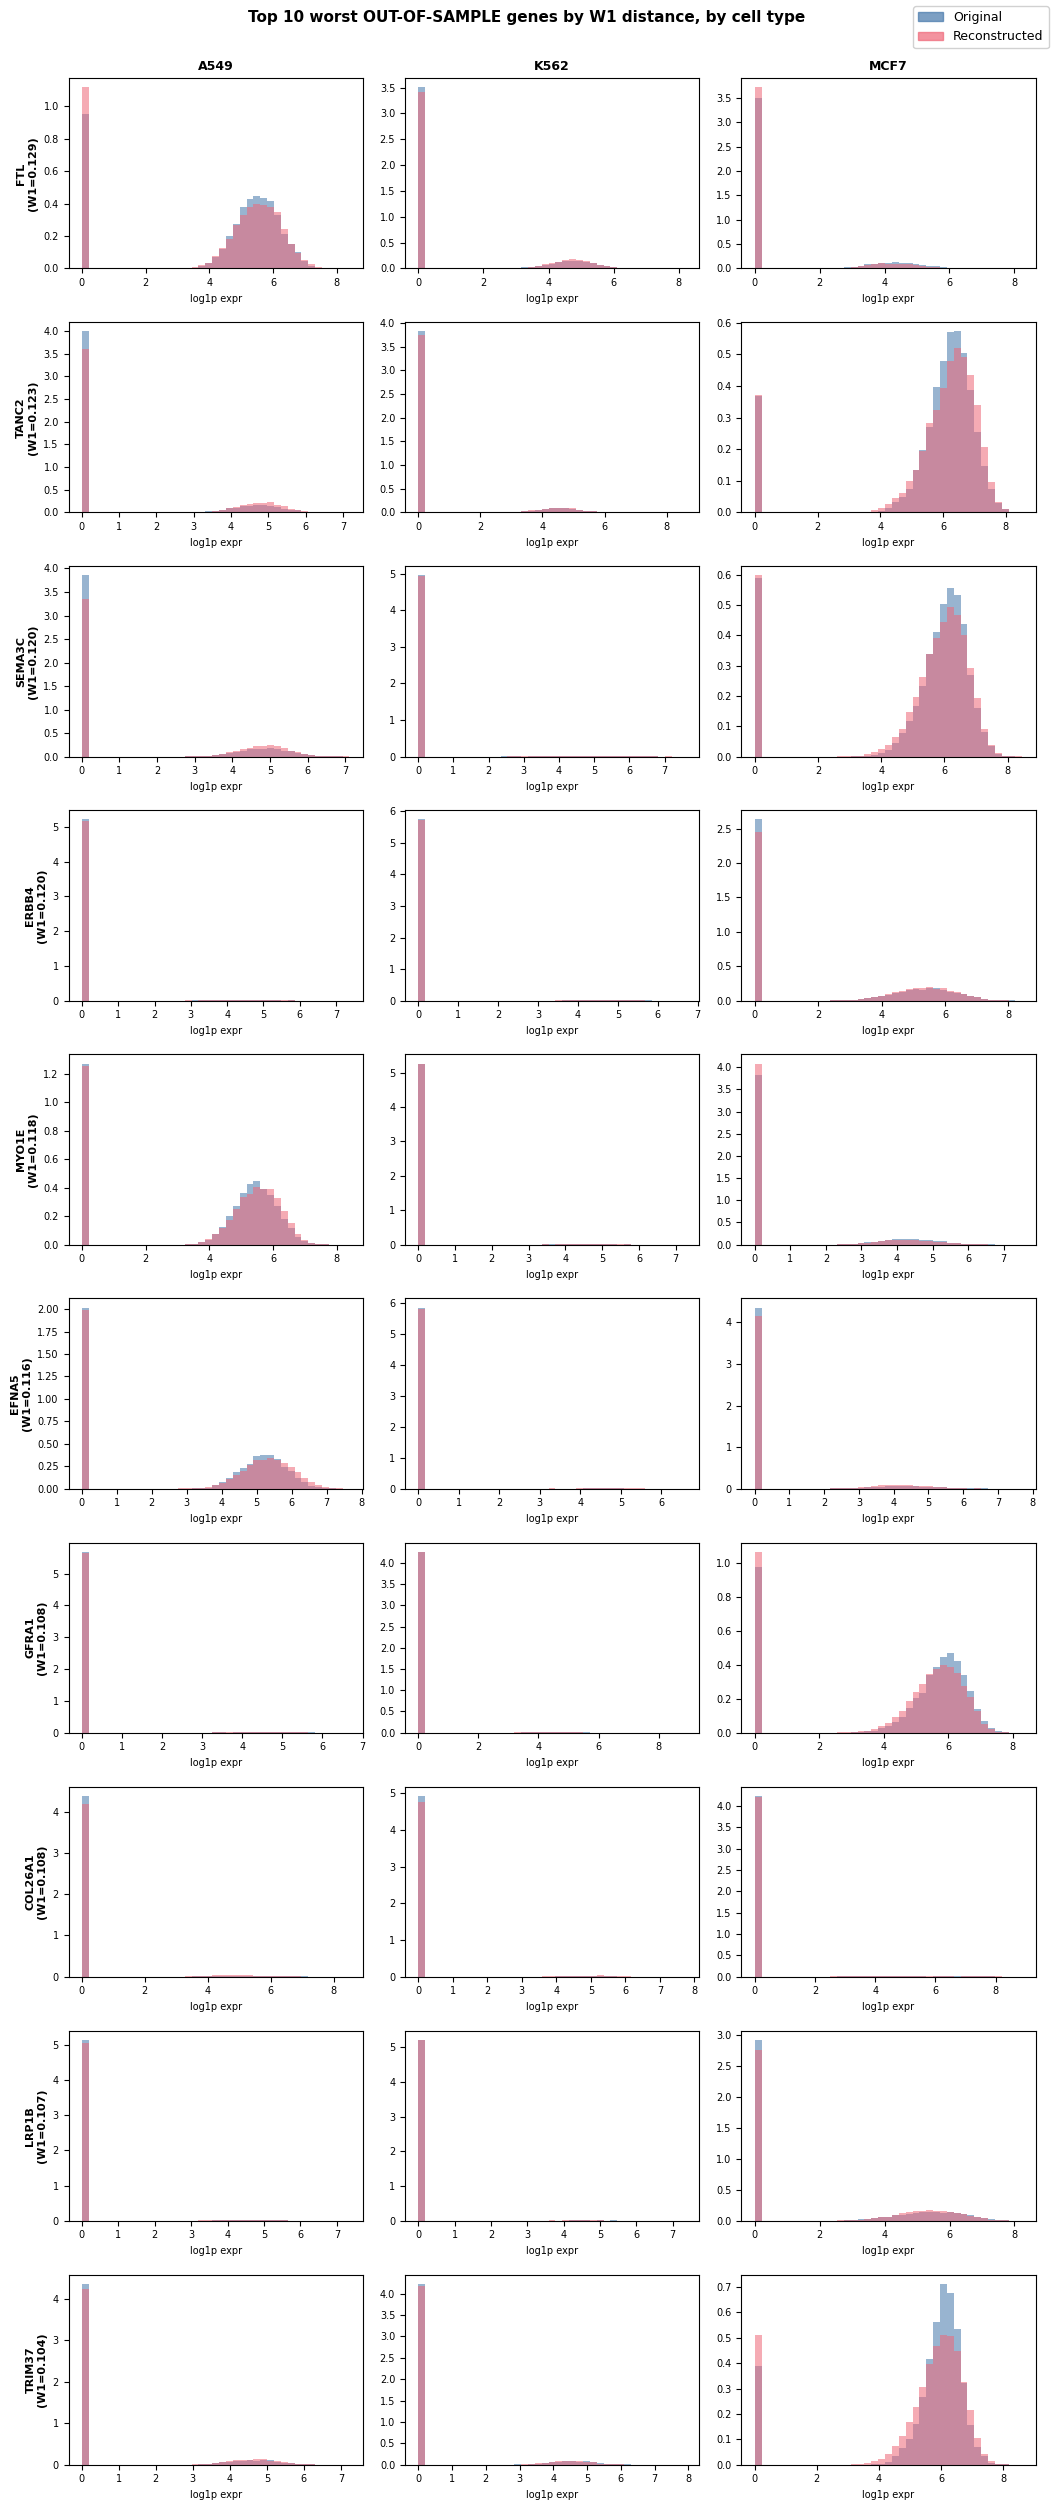

In [26]:
# --- out-of-sample evaluation ---
# get cells NOT in the training set
all_cell_names = set(adata_full_hvg.obs_names)
train_cell_set = set(train_cell_names)
oos_cell_names = sorted(all_cell_names - train_cell_set)
n_oos = len(oos_cell_names)
print(f"Out-of-sample cells: {n_oos} (train: {len(train_cell_set)}, total: {len(all_cell_names)})")

if n_oos > 0:
    adata_oos = adata_full_hvg[oos_cell_names, :].copy()

    x_recon_oos = model.reconstruct_log_norm(adata_oos, sample=True, device=device).cpu().numpy()

    X_raw_oos = adata_oos.X.toarray() if hasattr(adata_oos.X, "toarray") else adata_oos.X
    lib_size_oos = X_raw_oos.sum(axis=1, keepdims=True)
    x_orig_oos = np.log1p(X_raw_oos / np.maximum(lib_size_oos, 1) * 1e4)

    # per-gene W1 distance out-of-sample
    w1_oos = np.zeros(n_genes)
    for g in range(n_genes):
        w1_oos[g] = wasserstein_distance(x_orig_oos[:, g], x_recon_oos[:, g])

    print(f"In-sample  mean W1: {np.mean(w2_per_gene):.4f}")
    print(f"Out-of-sample mean W1: {np.mean(w1_oos):.4f}")

    # --- comparison histogram ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    ax = axes[0]
    ax.hist(
        w2_per_gene,
        bins=50,
        alpha=0.6,
        color="#4477AA",
        label=f"In-sample (mean={np.mean(w2_per_gene):.3f})",
        edgecolor="white",
    )
    ax.hist(
        w1_oos,
        bins=50,
        alpha=0.6,
        color="#EE6677",
        label=f"Out-of-sample (mean={np.mean(w1_oos):.3f})",
        edgecolor="white",
    )
    ax.set_xlabel("W1 distance")
    ax.set_ylabel("Number of genes")
    ax.set_title("Per-gene W1: in-sample vs out-of-sample")
    ax.legend()

    # scatter: in-sample vs out-of-sample W1 per gene
    ax = axes[1]
    ax.scatter(w2_per_gene, w1_oos, alpha=0.3, s=10, color="#4477AA")
    lim = max(w2_per_gene.max(), w1_oos.max()) * 1.05
    ax.plot([0, lim], [0, lim], "r--", alpha=0.5)
    ax.set_xlabel("In-sample W1")
    ax.set_ylabel("Out-of-sample W1")
    ax.set_title("Per-gene W1 correlation")

    # top 10 worst OOS genes
    top10_oos_idx = np.argsort(w1_oos)[::-1][:10]
    top10_oos_names = [gene_names[i] for i in top10_oos_idx]
    top10_oos_vals = w1_oos[top10_oos_idx]

    ax = axes[2]
    ax.barh(range(10), top10_oos_vals[::-1], color="#EE6677", alpha=0.7)
    ax.set_yticks(range(10))
    ax.set_yticklabels(top10_oos_names[::-1], fontsize=9)
    ax.set_xlabel("W1 distance")
    ax.set_title("Top 10 worst OOS genes")
    plt.tight_layout()
    plt.show()

    # --- histograms for top 10 worst OOS genes ---
    cell_types_oos = sorted(adata_oos.obs["cell_type"].unique())
    n_ct_oos = len(cell_types_oos)

    fig, axes = plt.subplots(10, n_ct_oos, figsize=(3.5 * n_ct_oos, 2.5 * 10), sharex=False, sharey=False)

    for row, g_idx in enumerate(top10_oos_idx):
        g_name = gene_names[g_idx]
        for col, ct in enumerate(cell_types_oos):
            ax = axes[row, col]
            mask = adata_oos.obs["cell_type"].values == ct

            orig_vals = x_orig_oos[mask, g_idx]
            recon_vals = x_recon_oos[mask, g_idx]

            x_max = max(orig_vals.max(), recon_vals.max())
            bins = np.linspace(0, x_max + 0.1, BINS)

            ax.hist(orig_vals, bins=bins, alpha=0.55, color=ORIG_COLOR, label="Original", density=True)
            ax.hist(recon_vals, bins=bins, alpha=0.55, color=RECON_COLOR, label="Reconstructed", density=True)

            if row == 0:
                ax.set_title(ct, fontsize=9, fontweight="bold")
            if col == 0:
                ax.set_ylabel(f"{g_name}\n(W1={w1_oos[g_idx]:.3f})", fontsize=8, fontweight="bold")
            ax.tick_params(labelsize=7)
            ax.set_xlabel("log1p expr", fontsize=7)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=ORIG_COLOR, alpha=0.7, label="Original"),
        plt.Rectangle((0, 0), 1, 1, color=RECON_COLOR, alpha=0.7, label="Reconstructed"),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.9)
    plt.suptitle(
        "Top 10 worst OUT-OF-SAMPLE genes by W1 distance, by cell type",
        fontsize=11,
        fontweight="bold",
        y=1.002,
    )
    plt.tight_layout()
    plt.show()
else:
    print("No out-of-sample cells (all cells used for training)")